# Data Preprocessing

This is an accompanying notebook for the Data Preprocessing lecture.

In [ ]:
# @title Import needed libraries
import pandas as pd
import numpy as np

In [ ]:
# @title Create and print DataFrame

# Sample noisy data
noisy_data  = {
    'ID': [101, 102, 103, 104, 105, 106, 107, 108, 108],
    'Gender': ['M', 'F', 'male', 'Female', 'f', 'MaLe', 'feMAle', 'FEMALE', 'FEMALE'],
    'Age': [25, '30', 22, '27', '30', '29', 35, 30, 30],
    'Score1': [88.5, 'N/A', 85.5, None, 90.0, np.nan, 85.5, 92.0, 92.0],
    'Score2': [80, 90, 88, 82, 91, 89, 86, 90, 90],
    'JoinDate': ['2021-01-15', '01/16/2021', 'January 17, 2021', '2021/01/18',
        '18-01-2021', '2021.01.19', '2021/12/31', '2021-01-15', '2021-01-15']
}

# Create DataFrame
df = pd.DataFrame(noisy_data)

# Print DataFrame content
df

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.5,80,2021-01-15
1,102,F,30,N/A,90,01/16/2021
2,103,male,22,85.5,88,"January 17, 2021"
3,104,Female,27,None,82,2021/01/18
4,105,f,30,90.0,91,18-01-2021
5,106,MaLe,29,NaN,89,2021.01.19
6,107,feMAle,35,85.5,86,2021/12/31
7,108,FEMALE,30,92.0,90,2021-01-15
8,108,FEMALE,30,92.0,90,2021-01-15


## 1. Data Cleaning

### 1.1 Handle Multiple Representations

In [ ]:
# @title View column info with `unique()`

df["Gender"].unique()

array(['M', 'F', 'male', 'Female', 'f', 'MaLe', 'feMAle', 'FEMALE'],
      dtype=object)

In [ ]:
# @title Modify column with `map()`

# Update column
df["Gender"] = df["Gender"].map(lambda x: "M" if x.lower().startswith("m") else "F")

# Inspect if update was correct
df["Gender"]

,Gender
0,M
1,F
2,M
3,F
4,F
5,M
6,F
7,F
8,F


### 1.2 Handle Incorrect Data Type

In [ ]:
# @title View column info with `info()`

df["Age"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9 entries, 0 to 8
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
9 non-null      object
dtypes: object(1)
memory usage: 204.0+ bytes


In [ ]:
# @title Use `to_numeric()` to typecast the entire column into int

# Convert column to int
df["Age"] = pd.to_numeric(df["Age"])

# Inspect if update was correct
df["Age"]

,Age
0,25
1,30
2,22
3,27
4,30
5,29
6,35
7,30
8,30


### 1.3 Handle Default Values

In [ ]:
# @title Check the data type of the column

df["Score1"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9 entries, 0 to 8
Series name: Score1
Non-Null Count  Dtype 
--------------  ----- 
7 non-null      object
dtypes: object(1)
memory usage: 204.0+ bytes


In [ ]:
# @title Inspect rows that are strings or missing values

df.loc[pd.to_numeric(df["Score1"], errors='coerce').isna()]

# - pd.to_numeric is attempting to convert each element of the Score1 column to a number
# - errors='coerce' attempts to convert the missing values to NaN
# - We are expecting it to fail because the column contains strings and missing values
# - isna() will check if each element has a value or not, this will return a boolean Series
# - loc will return to us the subset of the DataFrame whose Score1 rows cannot be converted to a numeric value or has a missing value

,ID,Gender,Age,Score1,Score2,JoinDate
1,102,F,30,N/A,90,01/16/2021
3,104,F,27,None,82,2021/01/18
5,106,M,29,NaN,89,2021.01.19


In [ ]:
# @title Use `map()` to convert strings to None

# Update column
df["Score1"] = df["Score1"].map(lambda x: None if isinstance(x, str) else x)

# - The map() function should replace "N/A" with None
# - However, when pandas tried to infer the data type of the column again,
#   it automatically converted None to NaN

# Inspect column
df["Score1"]

,Score1
0,88.5
1,NaN
2,85.5
3,NaN
4,90.0
5,NaN
6,85.5
7,92.0
8,92.0


### 1.4 Handle Missing Data

In [ ]:
# @title Inspect rows with missing values

df.loc[df["Score1"].isna()]

,ID,Gender,Age,Score1,Score2,JoinDate
1,102,F,30,NaN,90,01/16/2021
3,104,F,27,NaN,82,2021/01/18
5,106,M,29,NaN,89,2021.01.19


In [ ]:
# @title Option 1: Delete all rows containing missing data

df_cleaned = df.dropna()

# Inspect cleaned df
df_cleaned

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.5,80,2021-01-15
2,103,M,22,85.5,88,"January 17, 2021"
4,105,F,30,90.0,91,18-01-2021
6,107,F,35,85.5,86,2021/12/31
7,108,F,30,92.0,90,2021-01-15
8,108,F,30,92.0,90,2021-01-15


In [ ]:
# @title Option 2: Replace missing data with mean

# Get mean of the column, NaN is ignored by default
mean = df["Score1"].mean()

# Replace NaN with mean
df["Score1"] = df["Score1"].fillna(mean)

# Inspect column
df["Score1"]

,Score1
0,88.500000
1,88.916667
2,85.500000
3,88.916667
4,90.000000
5,88.916667
6,85.500000
7,92.000000
8,92.000000


### 1.5 Handle Duplicate Data

In [ ]:
# @title Inspect rows with duplicate data

df[df.duplicated(keep=False)]

,ID,Gender,Age,Score1,Score2,JoinDate
7,108,F,30,92.0,90,2021-01-15
8,108,F,30,92.0,90,2021-01-15


In [ ]:
# @title Remove duplicate rows

df = df.drop_duplicates()

# Inspect DataFrame
df

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
1,102,F,30,88.916667,90,01/16/2021
2,103,M,22,85.500000,88,"January 17, 2021"
3,104,F,27,88.916667,82,2021/01/18
4,105,F,30,90.000000,91,18-01-2021
5,106,M,29,88.916667,89,2021.01.19
6,107,F,35,85.500000,86,2021/12/31
7,108,F,30,92.000000,90,2021-01-15


### 1.6 Handle Inconsistent Format

In [ ]:
# @title Use `apply()` and `to_datetime()` to clean inconsistent formats

def parse_dates(date_str):
  formats = [
    '%Y-%m-%d',      # 2021-01-15
    '%m/%d/%Y',      # 01/16/2021
    '%B %d, %Y',     # January 17, 2021
    '%Y/%m/%d',      # 2021/01/18
    '%d-%m-%Y',      # 18-01-2021
    '%Y.%m.%d'       # 2021.01.19
  ]

  for fmt in formats:
    try:
      return pd.to_datetime(date_str, format=fmt)
    except ValueError:
      continue
  return pd.NaT  # Return NaT if no format works

# Apply the custom parsing function
df['JoinDate'] = df['JoinDate'].apply(parse_dates)

# Inspect updated column
df['JoinDate']

/tmp/ipykernel_641/161897062.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['JoinDate'] = df['JoinDate'].apply(parse_dates)


,JoinDate
0,2021-01-15
1,2021-01-16
2,2021-01-17
3,2021-01-18
4,2021-01-18
5,2021-01-19
6,2021-12-31
7,2021-01-15


### Inspect Cleaned DataFrame

In [ ]:
df

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
1,102,F,30,88.916667,90,2021-01-16
2,103,M,22,85.500000,88,2021-01-17
3,104,F,27,88.916667,82,2021-01-18
4,105,F,30,90.000000,91,2021-01-18
5,106,M,29,88.916667,89,2021-01-19
6,107,F,35,85.500000,86,2021-12-31
7,108,F,30,92.000000,90,2021-01-15


### `inplace` Parameter

In [ ]:
# @title Create a DataFrame with missing values

missing_df = pd.DataFrame({"ColA": [10, np.nan, 20, np.nan, 30, np.nan, 40]})
missing_df

,ColA
0,10.0
1,NaN
2,20.0
3,NaN
4,30.0
5,NaN
6,40.0


In [ ]:
# @title `inplace = False` (default)

# Perform method
missing_df.dropna()

# Inspect original DataFrame
missing_df

,ColA
0,10.0
1,NaN
2,20.0
3,NaN
4,30.0
5,NaN
6,40.0


In [ ]:
# @title `inplace = True`

# Perform method
missing_df.dropna(inplace=True)

# Inspect original DataFrame
missing_df

,ColA
0,10.0
2,20.0
4,30.0
6,40.0


## 2 Data Preprocessing

### 2.1 Querying

In [ ]:
# @title Inspect DataFrame
df

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
1,102,F,30,88.916667,90,2021-01-16
2,103,M,22,85.500000,88,2021-01-17
3,104,F,27,88.916667,82,2021-01-18
4,105,F,30,90.000000,91,2021-01-18
5,106,M,29,88.916667,89,2021-01-19
6,107,F,35,85.500000,86,2021-12-31
7,108,F,30,92.000000,90,2021-01-15


In [ ]:
# @title Example 1: Select rows based on numerical value
df.query("Score1 >= 88")

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
1,102,F,30,88.916667,90,2021-01-16
3,104,F,27,88.916667,82,2021-01-18
4,105,F,30,90.000000,91,2021-01-18
5,106,M,29,88.916667,89,2021-01-19
7,108,F,30,92.000000,90,2021-01-15


In [ ]:
# @title Example 2: Select rows based on string value
df.query("Gender == 'M'")

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
2,103,M,22,85.500000,88,2021-01-17
5,106,M,29,88.916667,89,2021-01-19


In [ ]:
# @title Example 3: Select rows based on multiple conditions
df.query("Score1 >= 88 and Gender == 'M'")

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
5,106,M,29,88.916667,89,2021-01-19


In [ ]:
# @title Example 4: Select rows based on index
df.query("index > 4")

,ID,Gender,Age,Score1,Score2,JoinDate
5,106,M,29,88.916667,89,2021-01-19
6,107,F,35,85.500000,86,2021-12-31
7,108,F,30,92.000000,90,2021-01-15


In [ ]:
# @title Example 5: Select rows by comparing multiple columns
df.query("Score1 > Score2")

,ID,Gender,Age,Score1,Score2,JoinDate
0,101,M,25,88.500000,80,2021-01-15
3,104,F,27,88.916667,82,2021-01-18
7,108,F,30,92.000000,90,2021-01-15


In [ ]:
# @title Example 6: Select specific rows and columns

df.query("Score1 >= 88 and Gender == 'M'").loc[:, "ID":"Age"]

,ID,Gender,Age
0,101,M,25
5,106,M,29


### 2.2 Imputation

#### Drop Rows/Columns

In [ ]:
# @title Create DataFrame with missing values

data = {
  'Col_0': [1, 2, 3, 4],
  'Col_25': [5, 6, 7, np.nan],
  'Col_50': [9, 10, np.nan, np.nan],
  'Col_75': [13, np.nan, np.nan, np.nan]
}

missing_df = pd.DataFrame(data)
missing_df.index = ["Row_0", "Row_25", "Row_50", "Row_75"]
missing_df

,Col_0,Col_25,Col_50,Col_75
Row_0,1,5.0,9.0,13.0
Row_25,2,6.0,10.0,NaN
Row_50,3,7.0,NaN,NaN
Row_75,4,NaN,NaN,NaN


In [ ]:
# @title Set threshold to drop rows/columns with 75% or more missing values

t = 0.75

In [ ]:
# @title Drop columns with missing value less than the threshold t

df_cleaned = missing_df[missing_df.columns[missing_df.isnull().mean() < t]]
df_cleaned

,Col_0,Col_25,Col_50
Row_0,1,5.0,9.0
Row_25,2,6.0,10.0
Row_50,3,7.0,NaN
Row_75,4,NaN,NaN


In [ ]:
# @title Drop rows with missing value less than the threshold t:

df_cleaned = missing_df.loc[missing_df.isnull().mean(axis=1) < t]
df_cleaned

,Col_0,Col_25,Col_50,Col_75
Row_0,1,5.0,9.0,13.0
Row_25,2,6.0,10.0,NaN
Row_50,3,7.0,NaN,NaN


#### Numerical/Categorical Imputation

In [ ]:
# @title Create sample DataFrame

impu_data = {
  "Age": [25, np.nan, 30, 22, np.nan, 35, 28, np.nan, 26, 27],
  "SmokerStatus": ["Smoker", "Non-Smoker", np.nan, "Smoker", "Non-Smoker",
                    "Non-Smoker", np.nan, "Non-Smoker", "Non-Smoker", np.nan]
}

impu_df = pd.DataFrame(impu_data)
impu_df

,Age,SmokerStatus
0,25.0,Smoker
1,NaN,Non-Smoker
2,30.0,NaN
3,22.0,Smoker
4,NaN,Non-Smoker
5,35.0,Non-Smoker
6,28.0,NaN
7,NaN,Non-Smoker
8,26.0,Non-Smoker
9,27.0,NaN


In [ ]:
# @title Inspect summary info for the Age column

impu_df["Age"].describe()

,Age
count,7.000000
mean,27.571429
std,4.117327
min,22.000000
25%,25.500000
50%,27.000000
75%,29.000000
max,35.000000


In [ ]:
# @title Inspect summary info for the SmokerStatus column

impu_df["SmokerStatus"].describe()

,SmokerStatus
count,7
unique,2
top,Non-Smoker
freq,5


In [ ]:
# @title Replace missing info with `fillna()`

# Numerical imputation
median = impu_df["Age"].median()
impu_df["Age"] = impu_df["Age"].fillna(median)

# Categorical imputation
mode = impu_df["SmokerStatus"].mode()
impu_df["SmokerStatus"] = impu_df["SmokerStatus"].fillna(mode[0])

# Inspect updated DataFrame
impu_df

,Age,SmokerStatus
0,25.0,Smoker
1,27.0,Non-Smoker
2,30.0,Non-Smoker
3,22.0,Smoker
4,27.0,Non-Smoker
5,35.0,Non-Smoker
6,28.0,Non-Smoker
7,27.0,Non-Smoker
8,26.0,Non-Smoker
9,27.0,Non-Smoker


### 2.3 Binning

In [ ]:
# @title Create sample DataFrame

bin_data = {
  "Name": ["Alice", "Bob", "Charlie", "Diana", "Ethan",
            "Fiona", "George", "Hannah", "Ivan", "Julia"],
  "Age": [18, 22, 26, 31, 36, 41, 47, 53, 58, 61],
  "Location": ["Malate", "Ermita", "Cubao", "Poblacion", "BGC", "Kapitolyo",
                "San Miguel", "Diliman", "Legazpi Village", "Fort Bonifacio"]
}

bin_df = pd.DataFrame(bin_data)
bin_df

,Name,Age,Location
0,Alice,18,Malate
1,Bob,22,Ermita
2,Charlie,26,Cubao
3,Diana,31,Poblacion
4,Ethan,36,BGC
5,Fiona,41,Kapitolyo
6,George,47,San Miguel
7,Hannah,53,Diliman
8,Ivan,58,Legazpi Village
9,Julia,61,Fort Bonifacio


In [ ]:
# @title Binning Numerical Data

# Create age bins
age_bins = list(range(10, 80, 10))  # [10, 20, 30, 40, 50, 60, 70]
age_labels = [f"{age_bins[i]}–{age_bins[i+1]-1}" for i in range(len(age_bins)-1)]

# Bin to AgeRange
bin_df["AgeRange"] = pd.cut(bin_df["Age"], bins=age_bins, labels=age_labels, right=False)

# Inspect DataFrame
bin_df

,Name,Age,Location,AgeRange
0,Alice,18,Malate,10–19
1,Bob,22,Ermita,20–29
2,Charlie,26,Cubao,20–29
3,Diana,31,Poblacion,30–39
4,Ethan,36,BGC,30–39
5,Fiona,41,Kapitolyo,40–49
6,George,47,San Miguel,40–49
7,Hannah,53,Diliman,50–59
8,Ivan,58,Legazpi Village,50–59
9,Julia,61,Fort Bonifacio,60–69


In [ ]:
# @title Binning Categorical Data

# Define mapping of Location to City bins
location_to_city = {
  "Malate": "Manila",
  "Ermita": "Manila",
  "San Miguel": "Manila",
  "Cubao": "Quezon",
  "Diliman": "Quezon",
  "Poblacion": "Makati",
  "Legazpi Village": "Makati",
  "BGC": "Taguig",
  "Fort Bonifacio": "Taguig",
  "Kapitolyo": "Pasig"
  # Other possible mappings
}

# Bin to City
bin_df["City"] = bin_df["Location"].map(location_to_city)

# Inspect DataFrame
bin_df

,Name,Age,Location,AgeRange,City
0,Alice,18,Malate,10–19,Manila
1,Bob,22,Ermita,20–29,Manila
2,Charlie,26,Cubao,20–29,Quezon
3,Diana,31,Poblacion,30–39,Makati
4,Ethan,36,BGC,30–39,Taguig
5,Fiona,41,Kapitolyo,40–49,Pasig
6,George,47,San Miguel,40–49,Manila
7,Hannah,53,Diliman,50–59,Quezon
8,Ivan,58,Legazpi Village,50–59,Makati
9,Julia,61,Fort Bonifacio,60–69,Taguig


### 2.4 Outlier Detection

In [ ]:
# @title Create sample DataFrame

# Seed for reproducibility
np.random.seed(42)

# Generate normal data
X = np.random.normal(loc=50, scale=10, size=100)
Y = 2 * X + np.random.normal(loc=0, scale=5, size=100)

# Add outliers
X_outliers = np.array([120, 130, 140])
Y_outliers = np.array([10, 300, 20])

# Combine data
X_full = np.concatenate([X, X_outliers])
Y_full = np.concatenate([Y, Y_outliers])

# Create DataFrame
outlier_df = pd.DataFrame({'X': X_full, 'Y': Y_full})

#### Visualization

In [ ]:
# @title Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

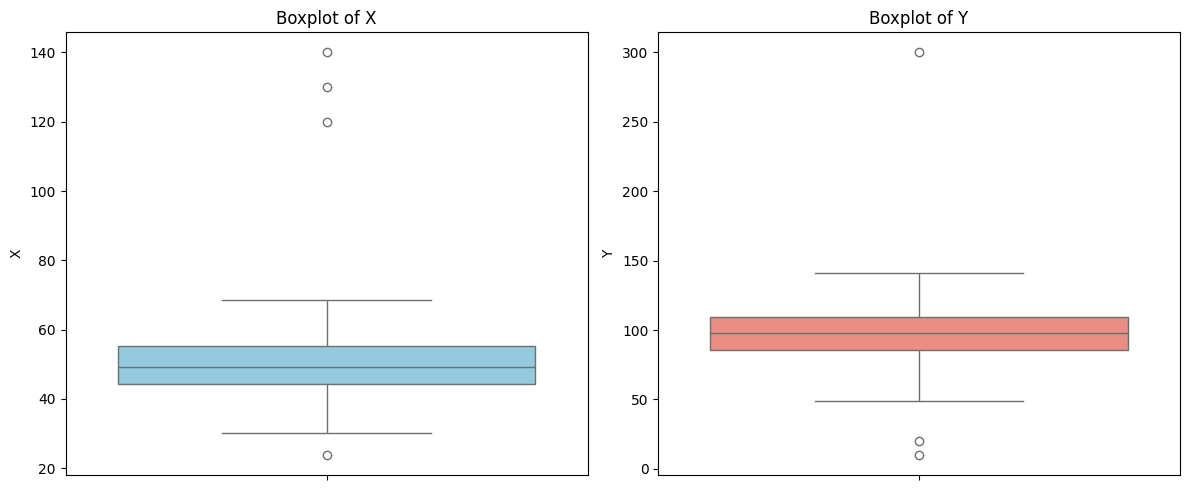

In [ ]:
# @title Boxplot

plt.figure(figsize=(12, 5))

# Boxplot for X
plt.subplot(1, 2, 1)
sns.boxplot(y=outlier_df['X'], color='skyblue')
plt.title("Boxplot of X")

# Boxplot for Y
plt.subplot(1, 2, 2)
sns.boxplot(y=outlier_df['Y'], color='salmon')
plt.title("Boxplot of Y")

plt.tight_layout()
plt.show()

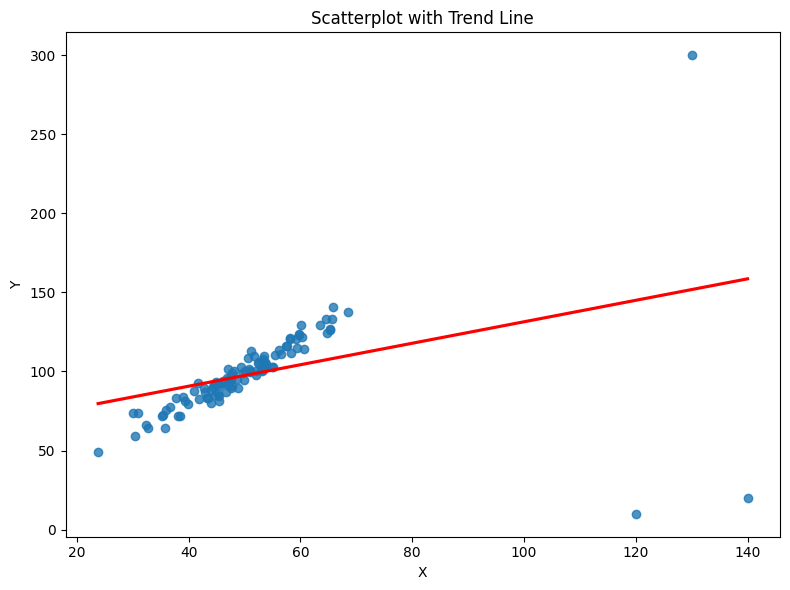

In [ ]:
# @title Scatterplot with Trend Line

plt.figure(figsize=(8, 6))

sns.regplot(data=outlier_df, x='X', y='Y', ci=False, line_kws={"color":"red"})

plt.title("Scatterplot with Trend Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

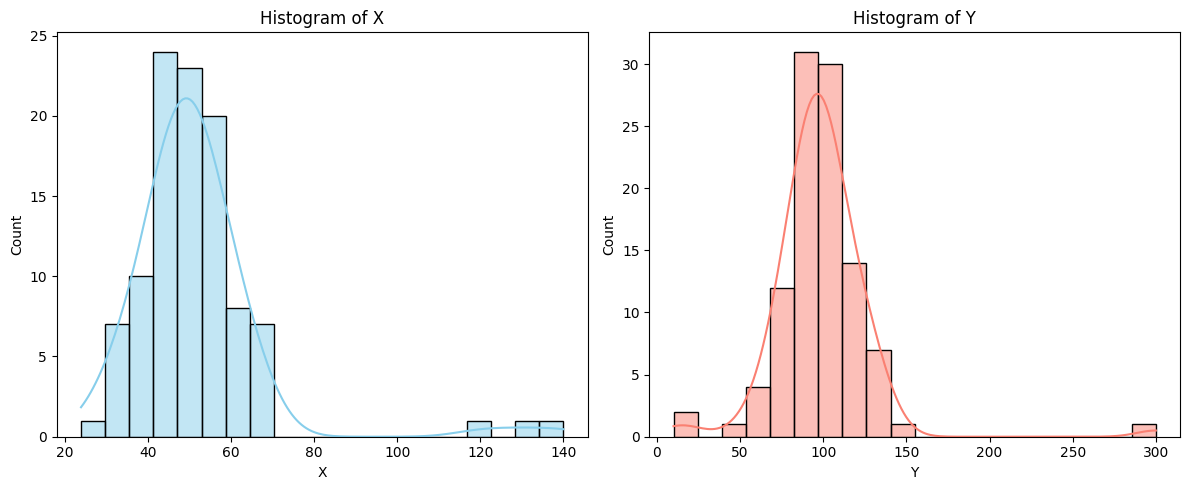

In [ ]:
# @title Histogram

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(outlier_df['X'], bins=20, kde=True, color='skyblue')
plt.title("Histogram of X")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(outlier_df['Y'], bins=20, kde=True, color='salmon')
plt.title("Histogram of Y")

plt.tight_layout()
plt.show()

#### Standard Deviation / Z-score

In [ ]:
# @title Import additional libraries
from scipy.stats import zscore

In [ ]:
# @title Detect outliers using z-scores

# Compute Z-scores for each column
z_scores = outlier_df.apply(zscore)

# Set threshold to 3, which is the common value for detecting outliers
t = 3

# Flag rows where any column has outliers
outliers = (np.abs(z_scores) > t).any(axis=1)

# Print outliers
outlier_df[outliers]

,X,Y
100,120.0,10.0
101,130.0,300.0
102,140.0,20.0


In [ ]:
# @title Detect outliers using the Empirical (68-95-97.5) Rule

# Set threshold to 3, which is the common value for detecting outliers
t = 3

# Calculate mean and standard deviation
means = outlier_df.mean()
stds = outlier_df.std()

# Define outlier bounds
lower_bound = means - (t * stds)
upper_bound = means + (t * stds)

# Flag rows where any column has outliers
outliers = ((outlier_df < lower_bound) | (outlier_df > upper_bound)).any(axis=1)

# Print outliers
outlier_df[outliers]

,X,Y
100,120.0,10.0
101,130.0,300.0
102,140.0,20.0


#### Percentiles

In [ ]:
# @title Inspect DataFrame summary information

outlier_df.describe()

,X,Y
count,103.000000,103.000000
mean,51.321878,98.383100
std,16.417675,29.236931
min,23.802549,10.000000
25%,44.185369,85.356967
50%,49.279899,97.782903
75%,55.279137,109.722577
max,140.000000,300.000000


In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = outlier_df.quantile(0.25)
Q3 = outlier_df.quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag rows where any column has outliers
outliers = ((outlier_df < lower_bound) | (outlier_df > upper_bound)).any(axis=1)

# Print outliers
outlier_df[outliers]

,X,Y
74,23.802549,48.988552
100,120.000000,10.000000
101,130.000000,300.000000
102,140.000000,20.000000


### 2.5 One Hot Encoding

In [ ]:
# @title Create sample DataFrame

ohe_data = {
  "Item": [1, 2, 3, 4, 5],
  "Color": ["Red", "Blue", "Red", "Green", "Blue"]
}

ohe_df = pd.DataFrame(ohe_data)

ohe_df

,Item,Color
0,1,Red
1,2,Blue
2,3,Red
3,4,Green
4,5,Blue


In [ ]:
# @title Get boolean representation

boolean_cols = pd.get_dummies(ohe_df["Color"], dtype=int)
boolean_cols

# The dtype is bool by default

,Blue,Green,Red
0,0,0,1
1,1,0,0
2,0,0,1
3,0,1,0
4,1,0,0


In [ ]:
# @title Update DataFrame

ohe_df = ohe_df.join(boolean_cols) #.drop("Color", axis=1)
ohe_df

,Item,Color,Blue,Green,Red
0,1,Red,0,0,1
1,2,Blue,1,0,0
2,3,Red,0,0,1
3,4,Green,0,1,0
4,5,Blue,1,0,0


### 2.6 Log Transformation

In [ ]:
# @title Create sample DataFrame

# Seed for reproducibility
np.random.seed(42)

# Generate skewed data
X = np.random.exponential(scale=20, size=100)
Y = 2 * X + np.random.normal(loc=0, scale=5, size=100)

# Create DataFrame
skewed_df = pd.DataFrame({"X": X, "Y": Y})

In [ ]:
# @title Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

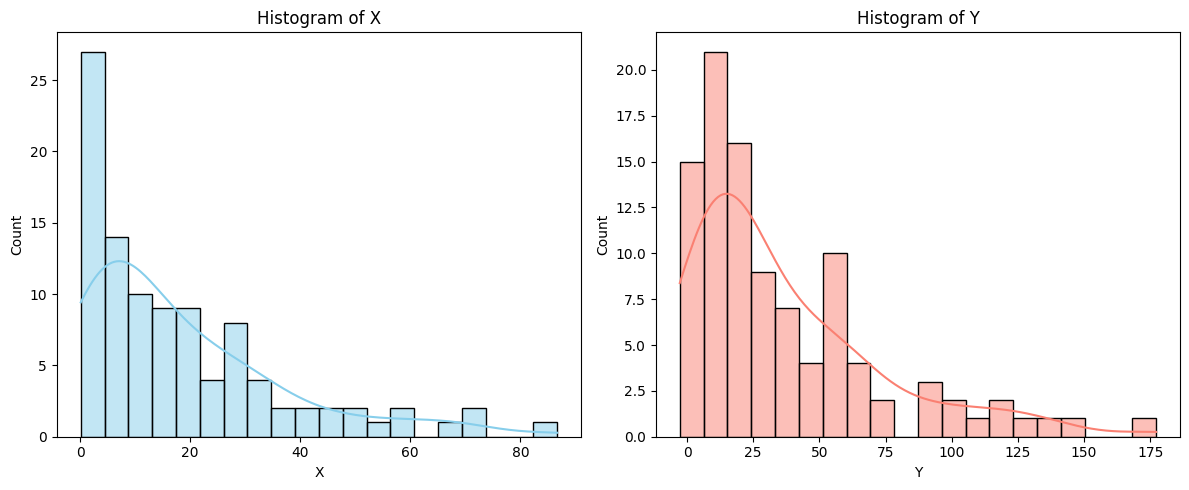

In [ ]:
# @title View Distribution (Original Data)

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(skewed_df['X'], bins=20, kde=True, color='skyblue')
plt.title("Histogram of X")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(skewed_df['Y'], bins=20, kde=True, color='salmon')
plt.title("Histogram of Y")

plt.tight_layout()
plt.show()

In [ ]:
# @title Apply log transformation

# Duplicate DataFrame
log_df = skewed_df.copy()

# Apply log transformation
log_df["X"] = np.log(log_df["X"])
log_df["Y"] = np.log(log_df["Y"])

# Inspect skewed_df
print(skewed_df.head())

# Inspect log_df
print(log_df.head())

           X           Y
0   9.385362   19.205959
1  60.202429  118.909820
2  26.334914   53.128632
3  18.258851   26.579858
4   3.392497    5.686635
          X         Y
0  2.239151  2.955221
1  4.097713  4.778365
2  3.270896  3.972716
3  2.904650  3.280154
4  1.221566  1.738119


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


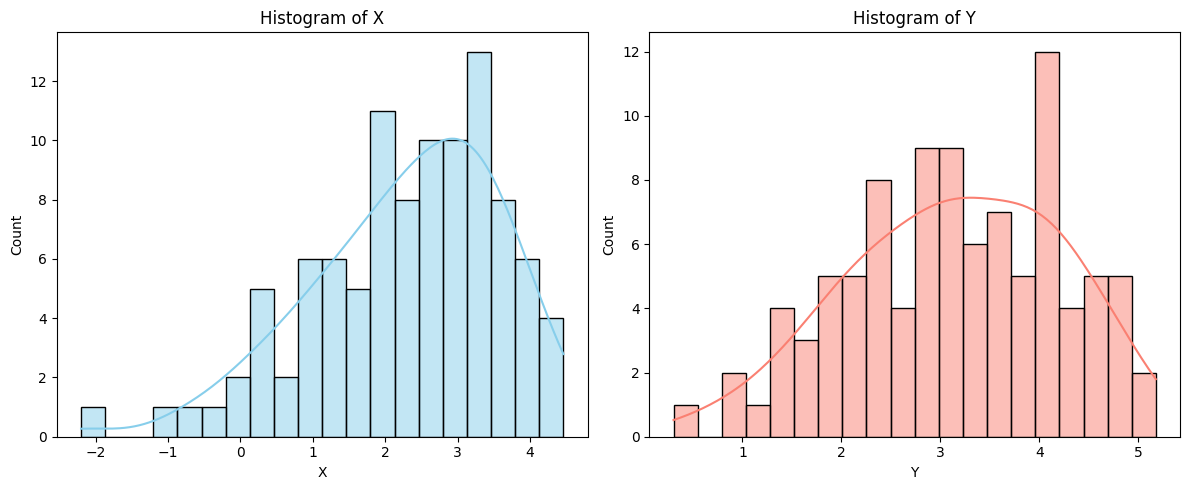

In [ ]:
# @title View Distribution (Log Transformed Data)

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(log_df['X'], bins=20, kde=True, color='skyblue')
plt.title("Histogram of X")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(log_df['Y'], bins=20, kde=True, color='salmon')
plt.title("Histogram of Y")

plt.tight_layout()
plt.show()

### 2.7 Aggregation

In [ ]:
# @title Create sample DataFrame

aggre_data = {
  "Age": [25, 24, 30, 22, 31, 35, 28, 27, 26, 27],
  "Location": ["Manila", "BGC", "QC", "BGC", "BGC",
               "Manila", "Manila", "QC", "Manila", "Manila"]
}

aggre_df = pd.DataFrame(aggre_data)
aggre_df

,Age,Location
0,25,Manila
1,24,BGC
2,30,QC
3,22,BGC
4,31,BGC
5,35,Manila
6,28,Manila
7,27,QC
8,26,Manila
9,27,Manila


In [ ]:
# @title Aggregating Numerical Data

aggre_df["Age"].describe()

,Age
count,10.000000
mean,27.500000
std,3.749074
min,22.000000
25%,25.250000
50%,27.000000
75%,29.500000
max,35.000000


In [ ]:
# @title Aggregating Categorical Data

aggre_df["Location"].describe()

,Location
count,10
unique,3
top,Manila
freq,5


### 2.8 Column Transformation

In [ ]:
# @title Create sample DataFrame

col_trans_df = pd.DataFrame({"Name": [
    "Ted Mosby", "Pedro P. Perez", "Maria Gomez",
    "Robb Stark", "Tom Nook"]})

col_trans_df

,Name
0,Ted Mosby
1,Pedro P. Perez
2,Maria Gomez
3,Robb Stark
4,Tom Nook


In [ ]:
# @title Extract firstname and lastname to separate columns

# Define function for extracting the names
def extract_names(row):
  names = row["Name"].split(" ")
  row["First"] = names[0]
  row["Last"] = names[-1]
  return row

# Apply extract_names() to the DataFrame
col_trans_df = col_trans_df.apply(extract_names, axis=1)

# Inspect DataFrame
col_trans_df

,Name,First,Last
0,Ted Mosby,Ted,Mosby
1,Pedro P. Perez,Pedro,Perez
2,Maria Gomez,Maria,Gomez
3,Robb Stark,Robb,Stark
4,Tom Nook,Tom,Nook


### 2.9 Feature Scaling

In [ ]:
# @title Create sample DataFrame

fscale_data = {
  "Height": [163, 164.5, 162, 162.2, 180.2],
  "Income": [29000, 35000, 60000, 19000, 15000]
}

fscale_df = pd.DataFrame(fscale_data)
fscale_df

,Height,Income
0,163.0,29000
1,164.5,35000
2,162.0,60000
3,162.2,19000
4,180.2,15000


In [ ]:
# @title Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

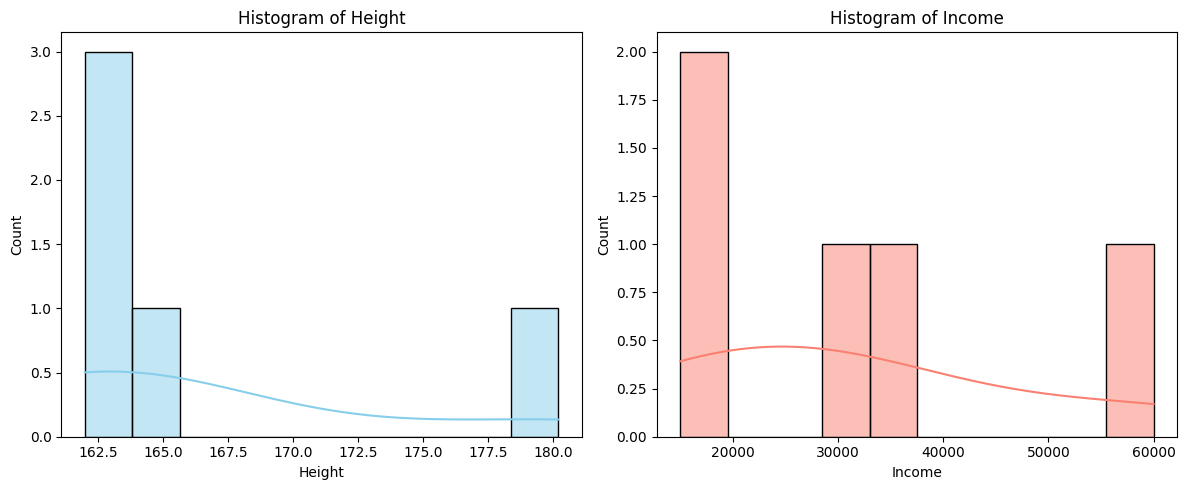

In [ ]:
# @title View Distribution (Original Data)

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(fscale_df['Height'], bins=10, kde=True, color='skyblue')
plt.title("Histogram of Height")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(fscale_df['Income'], bins=10, kde=True, color='salmon')
plt.title("Histogram of Income")

plt.tight_layout()
plt.show()

#### Normalization

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

In [ ]:
# @title Apply Normalization

normalized_df = round((fscale_df - fscale_df.min()) / (fscale_df.max() - fscale_df.min()), 2)
normalized_df

,Height,Income
0,0.05,0.31
1,0.14,0.44
2,0.00,1.00
3,0.01,0.09
4,1.00,0.00


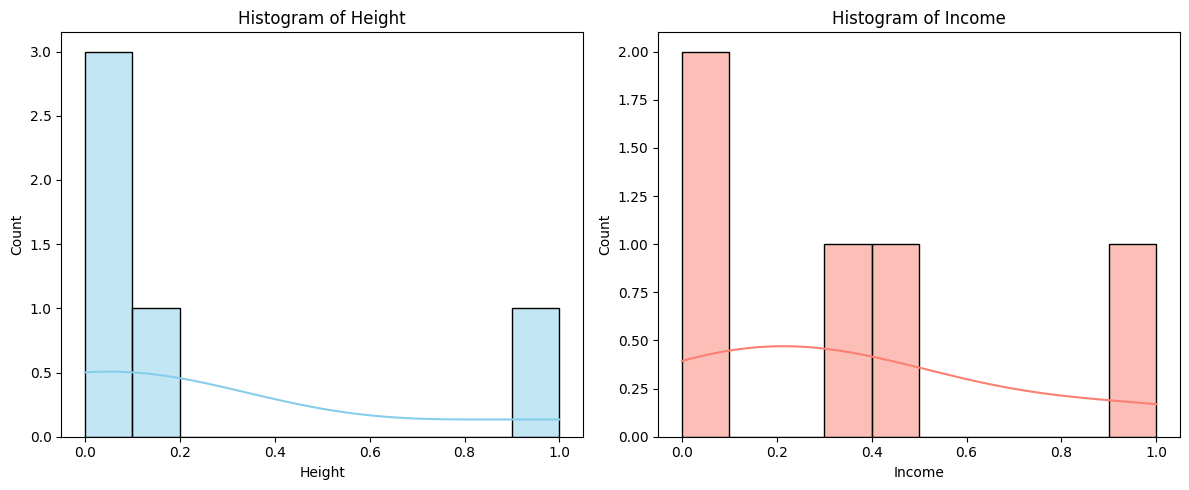

In [ ]:
# @title View Distribution (Normalized Data)

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(normalized_df['Height'], bins=10, kde=True, color='skyblue')
plt.title("Histogram of Height")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(normalized_df['Income'], bins=10, kde=True, color='salmon')
plt.title("Histogram of Income")

plt.tight_layout()
plt.show()

#### Standardization

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

In [ ]:
# @title Apply Standardization

standardized_df = round((fscale_df - fscale_df.mean()) / fscale_df.std(), 2)
standardized_df

,Height,Income
0,-0.43,-0.15
1,-0.24,0.19
2,-0.56,1.60
3,-0.54,-0.71
4,1.77,-0.94


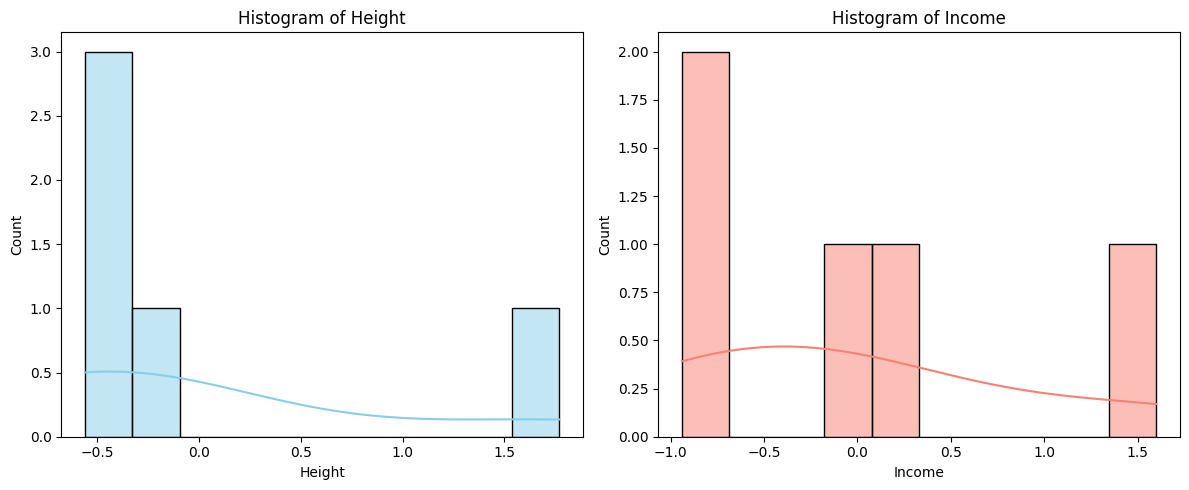

In [ ]:
# @title View Distribution (Standardized Data)

plt.figure(figsize=(12, 5))

# Histogram for X
plt.subplot(1, 2, 1)
sns.histplot(standardized_df['Height'], bins=10, kde=True, color='skyblue')
plt.title("Histogram of Height")

# Histogram for Y
plt.subplot(1, 2, 2)
sns.histplot(standardized_df['Income'], bins=10, kde=True, color='salmon')
plt.title("Histogram of Income")

plt.tight_layout()
plt.show()

### 2.10 Feature Engineering

In [ ]:
# @title Create sample DataFrame

fengine_data = {
  'Weight (kg)': [68, 82, 55, 90, 73, 60, 100, 49, 77, 65],
  'Height (m)': [1.75, 1.80, 1.60, 1.85, 1.78, 1.65, 1.90, 1.55, 1.82, 1.70]
}

fengine_df = pd.DataFrame(fengine_data)
fengine_df

,Weight (kg),Height (m)
0,68,1.75
1,82,1.80
2,55,1.60
3,90,1.85
4,73,1.78
5,60,1.65
6,100,1.90
7,49,1.55
8,77,1.82
9,65,1.70


In [ ]:
# @title Calculate BMI based on weight and height

fengine_df['BMI'] = (fengine_df['Weight (kg)'] / (fengine_df['Height (m)'] ** 2)).round(2)

fengine_df

,Weight (kg),Height (m),BMI
0,68,1.75,22.20
1,82,1.80,25.31
2,55,1.60,21.48
3,90,1.85,26.30
4,73,1.78,23.04
5,60,1.65,22.04
6,100,1.90,27.70
7,49,1.55,20.40
8,77,1.82,23.25
9,65,1.70,22.49
